## 🔹 Cell 1: Load MNIST Dataset

### 📌 What we are doing:
- Loading handwritten digit images
- Understanding data shape

In [3]:
from tensorflow.keras.datasets import mnist 
(x_train,y_train),(x_test,y_test)=mnist.load_data()
print("Train shape:",x_train.shape)
print("Test shape:",x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 🔹 Cell 2: Flatten & Normalize Data

### 📌 What we are doing:
- Converting 28x28 images into 1D vectors (784)
- Normalizing pixel values (0–255 → 0–1)

In [4]:
#Flatten
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)
#Normalize
x_train=x_train/255.0
x_test=x_test/255.0
print("New train shape:",x_train.shape)

New train shape: (60000, 784)


## 🔹 Cell 3: Build Neural Network

### 📌 What we are doing:
- Creating first neural network model
- Understanding layers and neurons

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dense(10,activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-26 23:48:25.357876: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 🔹 Cell 4: Compile & Train Neural Network

### 📌 What we are doing:
- Defining optimizer and loss function
- Training the model using gradient descent

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history=model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8673 - loss: 0.4617 - val_accuracy: 0.9662 - val_loss: 0.1248
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9611 - loss: 0.1315 - val_accuracy: 0.9745 - val_loss: 0.0994
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.0844 - val_accuracy: 0.9760 - val_loss: 0.0823
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9816 - loss: 0.0614 - val_accuracy: 0.9780 - val_loss: 0.0745
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9850 - loss: 0.0489 - val_accuracy: 0.9778 - val_loss: 0.0839
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0378 - val_accuracy: 0.9760 - val_loss: 0.0853
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0286 - val_accuracy: 0.9730 - val_loss: 0.1009
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9925 - loss: 0.0255 - 

In [20]:
model.save("model1.keras")

## 🔹 Cell 5: Evaluate Model

### 📌 What we are doing:
- Testing model on unseen data
- Checking final accuracy

In [5]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9731 - loss: 0.1020
Test Accuracy: 0.9771000146865845


## 🔹 Cell 6: Visualizing Predictions

### 📌 What we are doing:
- Showing actual image
- Comparing predicted vs actual label

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


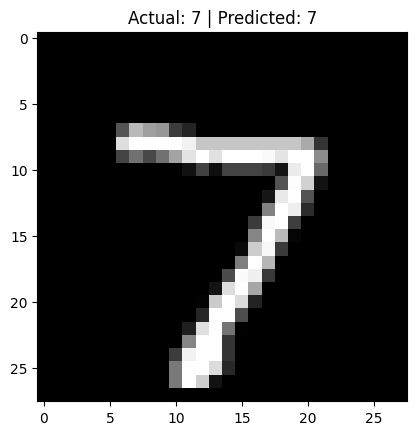

In [6]:
import matplotlib.pyplot as plt 
import numpy as np 
predictions=model.predict(x_test)
index=0
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Actual: {y_test[index]} | Predicted: {np.argmax(predictions[index])}")
plt.show()

## 🔹 Cell 7: Improved Neural Network

### 📌 What we are doing:
- Adding more layers
- Increasing learning capacity

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model2=Sequential([
    Dense(256,activation='relu',input_shape=(784,)),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2=model2.fit(
    x_train,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8840 - loss: 0.3838 - val_accuracy: 0.9617 - val_loss: 0.1333
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9695 - loss: 0.0969 - val_accuracy: 0.9735 - val_loss: 0.0900
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9823 - loss: 0.0588 - val_accuracy: 0.9783 - val_loss: 0.0783
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9860 - loss: 0.0428 - val_accuracy: 0.9735 - val_loss: 0.0951
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9897 - loss: 0.0332 - val_accuracy: 0.9800 - val_loss: 0.0833
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9797 - val_loss: 0.0820
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9925 - loss: 0.0221 - val_accuracy: 0.9830 - val_loss: 0.0759
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9938 - loss: 0.0177 - 

In [21]:
model2.save("model2.keras")

## 🔹 Cell 8: Dropout (Prevent Overfitting)

### 📌 What we are doing:
- Adding dropout layers
- Reducing overfitting

In [8]:
from tensorflow.keras.layers import Dropout
model3=Sequential([
    Dense(256,activation='relu',input_shape=(784,)),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax')
])
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history3=model3.fit(
    x_train,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8302 - loss: 0.5387 - val_accuracy: 0.9698 - val_loss: 0.1015
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9526 - loss: 0.1587 - val_accuracy: 0.9740 - val_loss: 0.0801
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9634 - loss: 0.1180 - val_accuracy: 0.9797 - val_loss: 0.0723
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9684 - loss: 0.1027 - val_accuracy: 0.9807 - val_loss: 0.0697
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9729 - loss: 0.0891 - val_accuracy: 0.9813 - val_loss: 0.0664
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9758 - loss: 0.0792 - val_accuracy: 0.9810 - val_loss: 0.0624
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9780 - loss: 0.0707 - val_accuracy: 0.9805 - val_loss: 0.0711
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9803 - loss: 0.0659 - 

In [22]:
model3.save("model3.keras")

# CNN

## 🔹 Cell CNN1: Prepare Data for CNN

### 📌 What we are doing:
- Reshaping images for CNN input
- Keeping spatial structure

In [5]:
# Reshape for CNN
x_train_cnn = x_train.reshape(60000, 28, 28, 1)
x_test_cnn = x_test.reshape(10000, 28, 28, 1)

print("New shape:", x_train_cnn.shape)

New shape: (60000, 28, 28, 1)


## 🔹 Cell CNN2: Build CNN Model

### 📌 What we are doing:
- Creating convolutional neural network
- Learning spatial features from images

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
model_cnn=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

## 🔹 Cell CNN3: Train CNN Model

### 📌 What we are doing:
- Compiling CNN model
- Training it on image data

In [11]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_cnn=model_cnn.fit(
    x_train_cnn,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9060 - loss: 0.3110 - val_accuracy: 0.9812 - val_loss: 0.0650
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9834 - loss: 0.0530 - val_accuracy: 0.9857 - val_loss: 0.0474
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9903 - loss: 0.0307 - val_accuracy: 0.9842 - val_loss: 0.0548
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.9878 - val_loss: 0.0514
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9865 - val_loss: 0.0567
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9967 - loss: 0.0089 - val_accuracy: 0.9883 - val_loss: 0.0507
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9979 - loss: 0.0065 - val_accuracy: 0.9870 - val_loss: 0.0660
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9985 -

In [23]:
model_cnn.save("model_cnn.keras")

## 🔹 Cell CNN4: Evaluate CNN Model

### 📌 What we are doing:
- Testing CNN on unseen data
- Checking real performance

In [12]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test)

print("CNN Test Accuracy:", test_acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9814 - loss: 0.0775
CNN Test Accuracy: 0.9855999946594238


## 🔹 Cell CNN5: Deep CNN Architecture

### 📌 What we are doing:
- Adding multiple convolution layers
- Learning more complex patterns

In [13]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
model_deep = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model_deep.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,690 (1.92 MB)

 Trainable params: 503,690 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

## 🔹 Cell CNN6: Train Deep CNN

### 📌 What we are doing:
- Training deeper CNN model
- Checking if performance improves

In [14]:
model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_deep=model_deep.fit(
    x_train_cnn,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.9171 - loss: 0.2598 - val_accuracy: 0.9875 - val_loss: 0.0454
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9887 - loss: 0.0369 - val_accuracy: 0.9907 - val_loss: 0.0325
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9911 - loss: 0.0262 - val_accuracy: 0.9892 - val_loss: 0.0407
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.9922 - val_loss: 0.0299
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9952 - loss: 0.0136 - val_accuracy: 0.9923 - val_loss: 0.0306
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9970 - loss: 0.0081 - val_accuracy: 0.9923 - val_loss: 0.0324
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9972 - loss: 0.0082 - val_accuracy: 0.9940 - val_loss: 0.0317
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9980 -

In [19]:
model_deep.save("model_deep.keras")

In [15]:
test_loss_deep,test_acc_deep=model_deep.evaluate(x_test_cnn,y_test)
print("Deep CNN Test Accuracy:",test_acc_deep)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9908 - loss: 0.0443
Deep CNN Test Accuracy: 0.9919000267982483


## 🔹 Cell CNN7: Data Augmentation

### 📌 What we are doing:
- Generating new variations of images
- Improving generalization

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen=ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train_cnn)

In [25]:
history_aug=model_cnn.fit(
    datagen.flow(x_train_cnn,y_train,batch_size=32),
    epochs=10,
    validation_data=(x_test_cnn,y_test)
)

Epoch 1/10
   4/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.7630 - loss: 1.0129 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9366 - loss: 0.2252 - val_accuracy: 0.9868 - val_loss: 0.0409
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9719 - loss: 0.0884 - val_accuracy: 0.9878 - val_loss: 0.0372
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9825 - loss: 0.0569 - val_accuracy: 0.9866 - val_loss: 0.0447
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9822 - loss: 0.0589 - val_accuracy: 0.9897 - val_loss: 0.0339
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9840 - loss: 0.0537 - val_accuracy: 0.9888 - val_loss: 0.0349
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9850 - loss: 0.0477 - val_accuracy: 0.9885 - val_loss: 0.0345
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9855 - loss: 0.04

# Cell CNN8: Batch Normalization

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
from tensorflow.keras.layers import BatchNormalization
model_bn=Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    
    Dense(10, activation='softmax')
])

2026-03-27 19:07:39.239337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774638459.483668      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774638459.549398      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774638460.083235      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774638460.083289      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774638460.083293      55 computation_placer.cc:177] computation placer alr

In [2]:
model_bn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,778 (4.58 MB)

 Trainable params: 1,200,330 (4.58 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_bn=model_bn.fit(
    x_train_cnn,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 97s 56ms/step - accuracy: 0.9446 - loss: 0.1821 - val_accuracy: 0.9883 - val_loss: 0.0402
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - accuracy: 0.9886 - loss: 0.0391 - val_accuracy: 0.9878 - val_loss: 0.0381
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 93s 55ms/step - accuracy: 0.9919 - loss: 0.0278 - val_accuracy: 0.9885 - val_loss: 0.0378
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 93s 55ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9913 - val_loss: 0.0325
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 55ms/step - accuracy: 0.9964 - loss: 0.0114 - val_accuracy: 0.9903 - val_loss: 0.0358
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - accuracy: 0.9967 - loss: 0.0106 - val_accuracy: 0.9902 - val_loss: 0.0409
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - accuracy: 0.9973 - loss: 0.0081 - val_accuracy: 0.9897 - val_loss: 0.0397
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - accuracy: 0.9978 -

## 🔹 Transfer Learning (Industry-Level Deep Learning)

### 📌 What we are doing:
- Using a pre-trained model (MobileNetV2)
- Reusing learned features
- Training only final layers for our task

### 💡 Why?
- Faster training
- Better performance
- No need for huge dataset

## 🔹 Imports for Transfer Learning

In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
import numpy as np 

2026-03-27 20:47:06.068421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774644426.334681      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774644426.412277      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774644427.041835      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774644427.041888      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774644427.041893      55 computation_placer.cc:177] computation placer alr

## 🔹 Prepare Data for Transfer Learning

### 📌 Problem:
- MNIST is grayscale (1 channel)
- Pretrained models expect RGB (3 channels)

### 📌 Solution:
- Convert 1 channel → 3 channels

## 🔹 Resize Images for Transfer Learning

### 📌 Why?
- MobileNet requires ≥ 32×32
- We resize MNIST from 28×28 → 32×32

In [8]:
import tensorflow as tf
x_train_resized=tf.image.resize(x_train_cnn,(32,32))
x_test_resized=tf.image.resize(x_test_cnn,(32,32))
x_train_rgb=tf.repeat(x_train_resized,3,axis=-1)
x_test_rgb=tf.repeat(x_test_resized,3,axis=-1)
print(x_train_rgb.shape)

2026-03-27 20:57:55.959085: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(60000, 32, 32, 3)


## 🔹 Load Pretrained Model (MobileNetV2)

### 📌 What we are doing:
- Loading model trained on ImageNet
- Removing top layers (classifier)

In [9]:
base_model=MobileNetV2(
    input_shape=(32,32,3),
    include_top=False,
    weights='imagenet'
)

/tmp/ipykernel_55/1639729706.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 🔹 Freeze Base Model

### 📌 Why?
- Keep learned features intact
- Train only new layers

In [10]:
base_model.trainable=False

## 🔹 Build Transfer Learning Model

### 📌 What we are doing:
- Adding custom classifier on top

In [11]:
model_t1=Sequential([
    base_model,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

## 🔹 Train Transfer Learning Model

### 📌 What we are doing:
- Training only final layers
- Using pretrained features

In [12]:
model_t1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_t1=model_t1.fit(
    x_train_rgb,y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 35ms/step - accuracy: 0.5683 - loss: 1.3322 - val_accuracy: 0.7010 - val_loss: 0.8871
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.6884 - loss: 0.9179 - val_accuracy: 0.7180 - val_loss: 0.8378
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.6995 - loss: 0.8734 - val_accuracy: 0.7275 - val_loss: 0.8037
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.7137 - loss: 0.8335 - val_accuracy: 0.7272 - val_loss: 0.7926
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.7173 - loss: 0.8170 - val_accuracy: 0.7367 - val_loss: 0.7749


## Evaluate Transfer Learning Model

In [13]:
test_loss_t1,test_acc_t1=model_t1.evaluate(x_test_rgb,y_test)
print("transfer learning test accuracy:",test_acc_t1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7121 - loss: 0.8487
transfer learning test accuracy: 0.7214000225067139


## 🔹 Fine-Tuning (Advanced Transfer Learning)

### 📌 What we are doing:
- Unfreezing some layers of pretrained model
- Allowing model to adapt to our dataset

### 💡 Why?
- Frozen model didn't perform well (~72%)
- Now we let it learn our patterns

## 🔹 Unfreeze Last Layers of Base Model

### 📌 Strategy:
- Keep most layers frozen
- Train only last few layers

In [15]:
for layer in base_model.layers[-20:]:
    layer.trainable=True

## 🔹 Compile with Low Learning Rate

### 📌 Why?
- We don’t want to destroy pretrained weights

In [16]:
from tensorflow.keras.optimizers import Adam
model_t1.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 🔹 Train Fine-Tuned Model

In [17]:
history_ft=model_t1.fit(
    x_train_rgb,y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 133s 73ms/step - accuracy: 0.6519 - loss: 2.9445 - val_accuracy: 0.5015 - val_loss: 1.4905
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 112s 66ms/step - accuracy: 0.8631 - loss: 0.4389 - val_accuracy: 0.8692 - val_loss: 0.4319
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 111s 65ms/step - accuracy: 0.9062 - loss: 0.3010 - val_accuracy: 0.9188 - val_loss: 0.2530
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 111s 66ms/step - accuracy: 0.9209 - loss: 0.2552 - val_accuracy: 0.9448 - val_loss: 0.1672
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 108s 64ms/step - accuracy: 0.9309 - loss: 0.2144 - val_accuracy: 0.9405 - val_loss: 0.1819
